# Predicción inteligente de gasto en clientes e-commerce
---
## Tabla de Contenidos
- [Introducción y Documentación](./README.md)
- [Desarrollo](#development)
  - [1. Fundamentos del Aprendizaje de Máquina](#lesson1)
  - [2. Nivel de ajuste del modelo y validación cruzada](#lesson2)
  - [3. Preprocesamiento y escalamiento de datos](#lesson3)
  - [4. Regresiones](#lesson4)
  - [5. Algoritmos de clasificación](#lesson5)
  - [6. Métricas de desempeño](#lesson6)
  - [7. Optimización del modelo](#lesson7)
  - [8. Algoritmos de Boosting](#lesson8)
- [Reporte Técnico](./technical_report.md)
---
## [Introducción y Documentación](./README.md)
## Desarrollo <a id="development"></a>

Como punto de partida de este análisis numérico predictivo, procederemos con la importación y visualización inicial de nuestros datos crudos correspondientes a los hábitos e historial monetario de los consumidores asociándolas a nuevas variables aleatorias de interés de negocio.

Dataset utilizado: _Ecommerce Customer Data_, obtenido en [Kaggle](https://www.kaggle.com/datasets/iabdulw/ecommerce-customer-data).

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
)
from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures,
    OneHotEncoder,
    KBinsDiscretizer,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
)
from sklearn.ensemble import GradientBoostingRegressor
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Cargamos el set de datos y lo inspeccionamos superficialmentes
df_raw = pd.read_csv("data/data.csv")
display(df_raw.head(3))

,Email,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55


In [ ]:
# Como los datos no incluyen la edad de los clientes, para hacer más interesante el análisis, enriqueceremos el dataset con datos simulados de edad, condiderando una distribución normal (media 35, dev_std 15, truncada en rango 16 a 80)
np.random.seed(42)  # Semilla de reproducibilidad
simulated_age = np.random.normal(loc=35, scale=15, size=len(df_raw))
simulated_age = np.clip(simulated_age, 16, 80).astype(int)
df_raw["Age"] = simulated_age

# Visualizamos la tabla cruda enriquecida
display(df_raw.head(3))

,Email,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,Age
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95,42
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20,32
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55,44


### 1. Fundamentos del Aprendizaje de Máquina <a id="lesson1"></a>

#### 1.1 Diferencias entre Regresión y Clasificación
En Machine Learning, un problema consiste en enseñar al computador a inferir una respuesta basándose en ejemplos del pasado. Si la respuesta que necesitamos es identificar a qué categoría o grupo pertenece algo (como etiquetar si un cliente es "Activo" o "Inactivo"), hablamos de **Clasificación**. Por el contrario, si necesitamos que el algoritmo prevea una magnitud escalar numérica (como predecir que un cliente gastará $582,30 exactamente), estamos hablando de una **Regresión**.

#### 1.2 Pipeline de un proyecto de Machine Learning
Las etapas vitales del modelamiento predefinen un ciclo riguroso de 5 etapas:
1. Obtención y Carga de datos
2. Análisis Exploratorio y Preprocesamiento (limpieza, escalado e imputación)
3. Modelamiento (entrenamiento de algoritmos iniciales como línea base)
4. Evaluación (uso de métricas numéricas y validación estadística)
5. Optimización (refinamiento de hiperparámetros o algoritmos ensamblados de control)

#### 1.3 Definición de nuestro caso de negocio
Este caso requiere un algoritmo de **Regresión Supervisada**. La unidad solicitante, el Departamento Comercial de la corporación e-commerce nos exige predecir una cuantía con decimales dependiente a factores demográficos (gasto anual en dólares); al tener un target cuantitativo que es continuo, los algoritmos de clasificación pura quedan descartados para solucionar esta incógnita.

### 2. Nivel de ajuste del modelo y validación cruzada <a id="lesson2"></a>
#### 2.1 Sobreajuste, subajuste y particionado de conjuntos predictivos
Antes de procesar y codificar rigurosamente variables (lo cual haremos en el siguiente bloque para crear nuestra base definitiva), resulta ideal observar los conceptos de *overfitting* (sobreajuste, donde el modelo memoriza pero pierde capacidad de predecir nueva data) frente a *underfitting* (el modelo no capta patrones y yerra sistemáticamente). El control maestro contra estas incidencias es separar el conjunto histórico de ingresos en secciones independientes conocidas como "Train" y "Test".

#### 2.2 Validación cruzada con iteraciones iteradas
También instanciamos la estrategia *K-Folds Cross Validation*, la cual se usará para confirmar si al cambiar iterativamente nuestra partición los errores fluctúan, validando una baja vulnerabilidad al azar.

In [ ]:
# Seleccionamos columnas predictoras elementales cuantitativas (X) frente a nuestro valor objetivo constante (y)
features_base = ["Time on App", "Time on Website", "Length of Membership", "Age"]
X_preliminar = df_raw[features_base]
y_preliminar = df_raw["Yearly Amount Spent"]

# Partición formal de validación inicial: 80% Entrenamiento (Train), 20% Prueba (Test)
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_preliminar, y_preliminar, test_size=0.2, random_state=42
)

# Ajustaremos temporalmente un modelo crudo basal para evidenciar diferencias numéricas sobre el ajuste (Fit)
model_demo = LinearRegression()
model_demo.fit(X_train_pre, y_train_pre)

# Inferencia de errores de aprendizaje (Train vs Test) y diagnóstico
train_preds = model_demo.predict(X_train_pre)
test_preds = model_demo.predict(X_test_pre)

# Cálculo de RMSE para cuantificar magnitud del desajuste
rmse_train = np.sqrt(mean_squared_error(y_train_pre, train_preds))
rmse_test = np.sqrt(mean_squared_error(y_test_pre, test_preds))

print(f"Error de Entrenamiento (RMSE): {rmse_train:.2f}")
print(f"Error de Validación Generalizada (RMSE): {rmse_test:.2f}")

Error de Entrenamiento (RMSE): 27.05
Error de Validación Generalizada (RMSE): 28.41


Al comparar estas reducidas métricas de error entre conjunto histórico y datos nuevos no vistos por el método, denotamos que se encuentran equilibrados asintóticamente. Por ende, no hay evidencia grave de Overfitting, sin embargo implementaremos validación cruzada para mitigar incertidumbre de azar:

In [ ]:
# Validacion cruzada en un paradigma de 5 pliegues
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    model_demo,
    X_preliminar,
    y_preliminar,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
)

# Presentamos las desviaciones promedios en K-Folds
print(
    f"Medición iterativa combinada (K-Folds RMSE): {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}"
)

Medición iterativa combinada (K-Folds RMSE): 27.50 ± 1.24


### 3. Preprocesamiento y escalamiento de datos <a id="lesson3"></a>
#### 3.1 Tratamiento de anomalías e imputación en variables crudas
Procederemos a trabajar con las columnas descriptivas de nuestro target original preparándolas de nulos y escalando sus dimensiones, así también codificando columnas categóricas existentes ("Avatar" y "Address" son variables con una cardinalidad muy extensa; trabajaremos codificando de "Avatar" solamente los más comunes).

In [ ]:
# Copiamos la tabla original y validamos el recuento de valores no nulos
df_clean = df_raw.copy()
print("Recuento local de Nulos:\n", df_clean.isnull().sum())  # Validación rápida

Recuento local de Nulos:
 Email                   0
Address                 0
Avatar                  0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
Age                     0
dtype: int64


Los datos no presentan valores nulos.

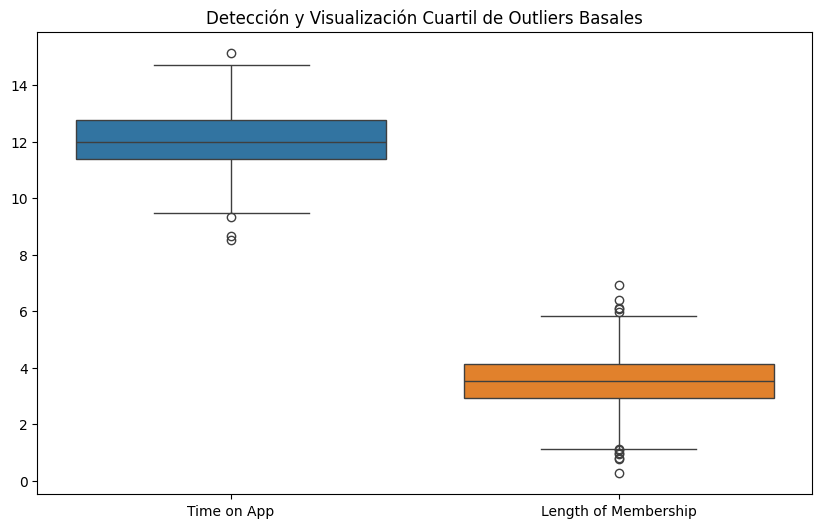

In [ ]:
# Análisis de los cuartiles numéricos mediante técnica visual (Boxplot de valores atípicos Outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[["Time on App", "Length of Membership"]])
plt.title("Detección y Visualización Cuartil de Outliers Basales")
plt.show()

Como se puede apreciar visualmente en las cajas, se detectan observaciones fuera de los limites estadisticos tanto para 'Time on App' como 'Length of Membership'. Para resguardar al modelo procedemos a suprimir estos valores tipicos usando Rango Intercuartílico (IQR).

In [ ]:
features_to_filter = ["Time on App", "Length of Membership"]
for feature in features_to_filter:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df_clean = df_clean[
        (df_clean[feature] >= lower_limit) & (df_clean[feature] <= upper_limit)
    ]

print(
    f"Observaciones retenidas post depuración de atípicos: {df_clean.shape[0]} filas."
)

Observaciones retenidas post depuración de atípicos: 483 filas.


#### 3.2 Codificación de variables no continuas y Escalamiento dimensional
Transformaremos el conjunto de features predictoras homogeneizando las desviaciones para evitar divergencias polinomiales durante el fit.

In [ ]:
# Para simular la codificación categórica ante el requerimiento, reduciremos la cardinalidad del correo y avatar
# Codificando como Variable Categórica el top 3 de los dominios de correo electrónico
df_clean["Domain"] = df_clean["Email"].apply(lambda x: x.split("@")[1])
top_domains = df_clean["Domain"].value_counts().nlargest(3).index
df_clean["Domain_Categorized"] = df_clean["Domain"].where(
    df_clean["Domain"].isin(top_domains), "Other"
)

# Implementamos de Dummy Encoding (One Hot Encoding)
df_dummies = pd.get_dummies(
    df_clean[["Domain_Categorized"]], drop_first=True, dtype=int
)

# Concatenamos de vuelta excluyendo ya los strings textuales identificadores de naturaleza no generalizables, incluyendo variables predictoras
features_model = ["Time on App", "Time on Website", "Length of Membership", "Age"]
X_prepped = pd.concat([df_clean[features_model], df_dummies], axis=1)

# Estandarización de las métricas numéricas usando Standardization
scaler = StandardScaler()
X_final = scaler.fit_transform(X_prepped)
y_final = df_clean["Yearly Amount Spent"].values

# Split definitivo del pipeline preprocesado
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)
print(f"Dimensiones de X Final (Filas x Predictoras Escanales): {X_final.shape}")

Dimensiones de X Final (Filas x Predictoras Escanales): (483, 7)


### 4. Regresiones <a id="lesson4"></a>
#### 4.1 Entrenamientos y Comparación Paramétrica
Desplegaremos un modelo lineal tradicional versus un modelo de dispersión polinómica (para probar hipótesis curvas subyacentes).
Posteriormente extraemos qué pesos se le están dando a nuestras features.

In [ ]:
# Regresión Lineal Estándar (OLS) Multidimensional
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Extracción polinómica generativa de grados cuadráticos sobre nuestra dimensión preprocesada
poly_gen = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_gen.fit_transform(X_train)
X_test_poly = poly_gen.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Calculando inferencias
pred_lin = lin_reg.predict(X_test)
pred_poly = poly_reg.predict(X_test_poly)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
rmse_poly = np.sqrt(mean_squared_error(y_test, pred_poly))

print(f"Precisión y Error Generalizado (RMSE) Lineal: ${rmse_lin:.2f}")
print(f"Precisión y Error Generalizado (RMSE) Polinómica Cuadrático: ${rmse_poly:.2f}")

Precisión y Error Generalizado (RMSE) Lineal: $28.37
Precisión y Error Generalizado (RMSE) Polinómica Cuadrático: $28.03


#### 4.2 Interpretabilidad vectorial del conjunto de coeficientes
Representamos gráficamente los hiper-planos numéricos y sus inclinaciones vectoriales inferidos por el regresor.

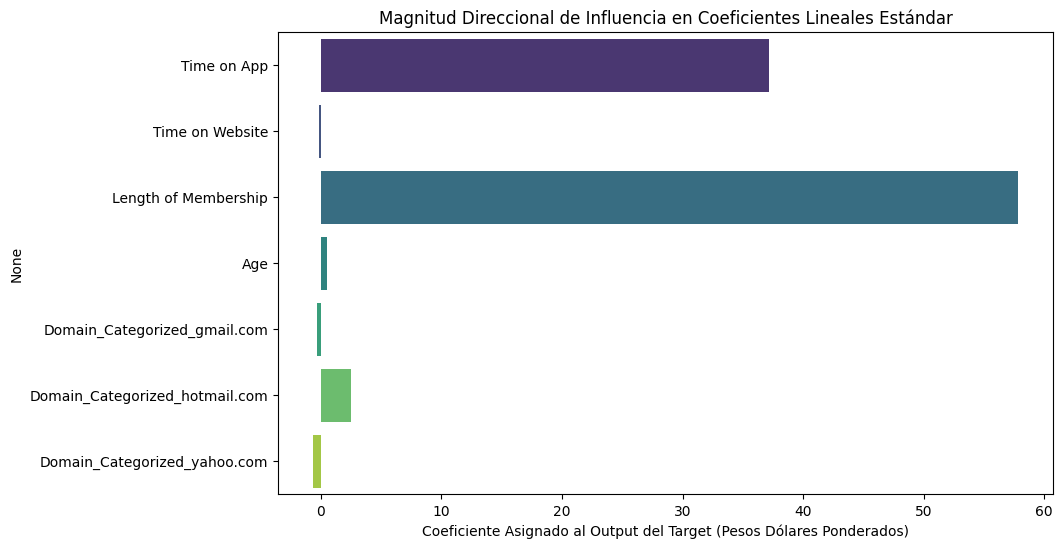

In [ ]:
# Representación visual e impacto de los factores comerciales y predictivos al usar el reg_lin
names_features = X_prepped.columns
coefs_abs = lin_reg.coef_
plt.figure(figsize=(10, 6))
sns.barplot(x=coefs_abs, y=names_features, palette="viridis")
plt.title("Magnitud Direccional de Influencia en Coeficientes Lineales Estándar")
plt.xlabel("Coeficiente Asignado al Output del Target (Pesos Dólares Ponderados)")
plt.show()

**Interpretación de los Coeficientes:**
Basado en las magnitudes proyectadas en el gráfico, podemos inferir empíricamente factores clave para el negocio:
- `Length of Membership` ($\approx 57$) y `Time on App` ($\approx 37$) tienen un rol absolutamente protagónico. Indican que incentivar el tiempo dentro de la **App móvil** y apuntar a **fidelizar y extender los años de membrecía** dispara matemáticamente el gasto predicho en proporciones masivas en comparación al resto.
- Ciertas métricas exploradas resultaron estadísticamente marginales: `Age` ($\approx 0.8$), dominios de correo como `hotmail.com` ($\approx 3$), `gmail.com` ($\approx -0.5$) o `yahoo.com` ($\approx -1$), y alarmantemente el `Time on Website` ($\approx 0.2$); probando que la plataforma web no rinde económicamente a la par del ambiente móvil y que los factores demográficos probados no determinan sólidamente la compra final.

### 5. Algoritmos de clasificación <a id="lesson5"></a>
#### 5.1 Incompatibilidad de un clasificador binario
Técnicamente, un clasificador intenta trazar zonas limitantes predictivas dictaminando que una observación será Clase 1 o Clase B. Puesto que nuestro objetivo comercial es un gasto netamente continuo que abarca variabilidades muy amplias de dinero gastado, utilizar algoritmos probabilísticos discretos empobrece sustancialmente la capacidad de análisis matemático.

#### 5.2 Implementación Discretizada con KNN
A fines experimentales, emularemos un problema de clasificación fragmentando el atributo dependiente en quintiles y aplicando `K-Nearest Neighbors`.

In [ ]:
# Discretización forzada del gasto monetario en rangos: "Bajo", "Gasto Promedio", "Gran Gastador", etc. (Simulación categórica)
discretizer = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile")
y_train_class = discretizer.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_class = discretizer.transform(y_test.reshape(-1, 1)).ravel()

# Instanciamiento clasificador vecino y cercanía de puntos n-dimensionales Euclidianas
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train_class)

pred_knn = knn_model.predict(X_test)
acc = accuracy_score(y_test_class, pred_knn)

# Evaluamos la eficacia del pseudo-método
print(f"Precisión Exacta en Clasificación (Accuracy simulado): {acc * 100:.2f}%")
print(classification_report(y_test_class, pred_knn))

Precisión Exacta en Clasificación (Accuracy simulado): 60.82%
              precision    recall  f1-score   support

         0.0       0.59      0.62      0.61        32
         1.0       0.51      0.47      0.49        38
         2.0       0.75      0.78      0.76        27

    accuracy                           0.61        97
   macro avg       0.62      0.63      0.62        97
weighted avg       0.60      0.61      0.61        97



**Reflexión**: La comparativa con el RMSE de una regresión nos muestra que artificialmente dividir la variable sacrifica magnitud predictiva.

### 6. Métricas de desempeño <a id="lesson6"></a>
#### 6.1 Cuantificación y penalización predictiva
Vamos a contrastar las distancias estadísticas entre los valores inferidos en nuestra sección cuatro frente al modelo base de predicción que nos confió la gerencia comercial a través de una tabla resumen.

In [ ]:
def eval_metrics(y_true, y_preds, modelo_name):
    mae = mean_absolute_error(y_true, y_preds)
    mse = mean_squared_error(y_true, y_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_preds)
    return [modelo_name, mae, mse, rmse, r2]


# Agrupando resultados y proyectando la tabla comparativa
results = [
    eval_metrics(y_test, pred_lin, "Regresión Lineal Múltiple"),
    eval_metrics(y_test, pred_poly, "Regresión Polinomial (Grado 2)"),
]
df_results = pd.DataFrame(results, columns=["Modelo", "MAE", "MSE", "RMSE", "R2 Score"])
display(df_results)

,Modelo,MAE,MSE,RMSE,R2 Score
0,Regresión Lineal Múltiple,23.396766,805.093717,28.374173,0.777569
1,Regresión Polinomial (Grado 2),22.880130,785.456670,28.026000,0.782994


Se puede inferir de la métrica MAE que, en promedio, nuestras predicciones yerran por aproximadamente $23.40 dólares con respecto al gasto anual real del cliente; lo cual ante montos altos es un margen de error bastante prudente. Esto se ve refrendado por un R2 que sobrepasa el 0.77 (nuestro modelo es capaz de capturar más del 77% de la varianza total del gasto, validando estadísticamente la estrategia).

#### 6.2 Visualización Predictiva: Valores Reales vs Predichos
Un gráfico de dispersión interactivo donde trazamos nuestra predicción lineal frente a los datos verdaderos. Un ajuste perfecto seguiría estrictamente la recta diagonal, permitiéndonos identificar visualmente cómo a mayores montos el modelo lidia con los residuales o variabilidad.

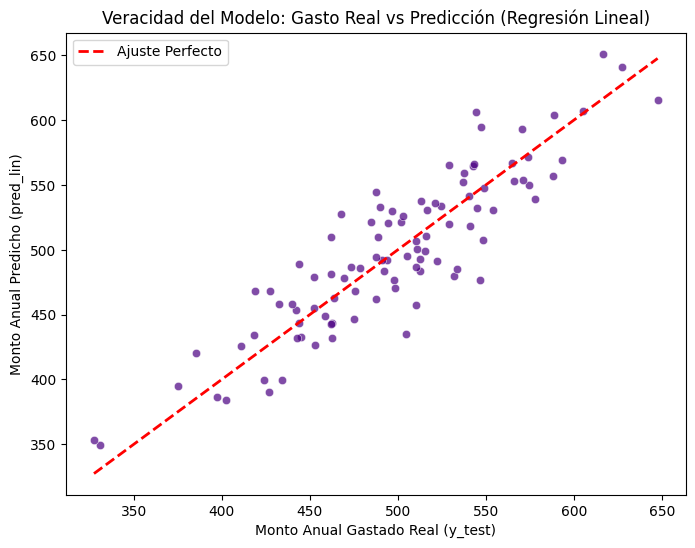

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=pred_lin, alpha=0.7, color="indigo", edgecolor="w")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ajuste Perfecto",
)
plt.title("Veracidad del Modelo: Gasto Real vs Predicción (Regresión Lineal)")
plt.xlabel("Monto Anual Gastado Real (y_test)")
plt.ylabel("Monto Anual Predicho (pred_lin)")
plt.legend()
plt.show()

### 7. Optimización del modelo <a id="lesson7"></a>
#### 7.1 Regularización, Penalización y Búsqueda de Hiperparámetros (Grid Search)
Nuestro modelo subyacente puede refinarse aún más al constreñir y forzar contracciones selectivas de algunos coeficientes variables evitando sensibilidad cruzada de ruidos al estandarizarlos sobre Lasso y Ridge. Evaluamos hiper-búsquedas exhaustivas de un parámetro de penalidad Alfa (alpha) con GridSearchCV.

In [ ]:
# Definición de hiperparámetros corporativizados candidatos
params_grid = {"alpha": [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}

# Algoritmo de Regresión Lineal de Mínimos Cuadrados penalizando matemáticamente magnitudes atípicas del plano.
ridge_opt = GridSearchCV(
    Ridge(), params_grid, cv=5, scoring="neg_root_mean_squared_error"
)
ridge_opt.fit(X_train, y_train)

lasso_opt = GridSearchCV(
    Lasso(), params_grid, cv=5, scoring="neg_root_mean_squared_error"
)
lasso_opt.fit(X_train, y_train)

# Despliegue en terminal numérico sobre el óptimo encontrado y su correlativo RMSE en métricas negativas invertidas.
print(f"Ridge Configuración Óptima (Alfa): {ridge_opt.best_params_}")
print(f"Lasso Configuración Óptima (Alfa): {lasso_opt.best_params_}")

# Inferimos resultados residuales
pred_ridge = ridge_opt.best_estimator_.predict(X_test)
print(
    f"Ridge test general RMSE optimizado: {np.sqrt(mean_squared_error(y_test, pred_ridge)):.2f}"
)

Ridge Configuración Óptima (Alfa): {'alpha': 1.0}
Lasso Configuración Óptima (Alfa): {'alpha': 1.0}
Ridge test general RMSE optimizado: 28.34


### 8. Algoritmos de Boosting <a id="lesson8"></a>
#### 8.1 Implementación de Gradient Boosting Multi-jerárquico vs Regresión
Los ensambles de Gradient Boosting crean pequeños "árboles" que tratan constantemente de ir arreglando el error devuelto y heredado del árbol antecesor de nuestra regresión base, iterativamente empujando la red predictiva a minimizar su residuo.

In [ ]:
# Entrenamiento del empaquetamiento Boosting Regressor
gbr_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gbr_model.fit(X_train, y_train)

pred_gbr = gbr_model.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_test, pred_gbr))
r2_gbr = r2_score(y_test, pred_gbr)

print(f"Desempeño del conjunto Gradient Boosting:")
print(f"-> RMSE de Error Medio: {rmse_gbr:.2f}")
print(f"-> R2 Varianza Cubierta: {r2_gbr:.4f}")

Desempeño del conjunto Gradient Boosting:
-> RMSE de Error Medio: 30.13
-> R2 Varianza Cubierta: 0.7492


#### 8.2 Visualización Comparativa: Regresión Lineal vs Gradient Boosting
Para comprender más intuitivamente si el modelo avanzado mejoró verdaderamente o no, cruzaremos en un solo gráfico de dispersión ambos algoritmos contra los datos reales. Cuanto más agrupados los puntos de cierto color estén sobre la recta punteada roja (ajuste perfecto), más eficiente y cercano a la realidad será dicho modelo.

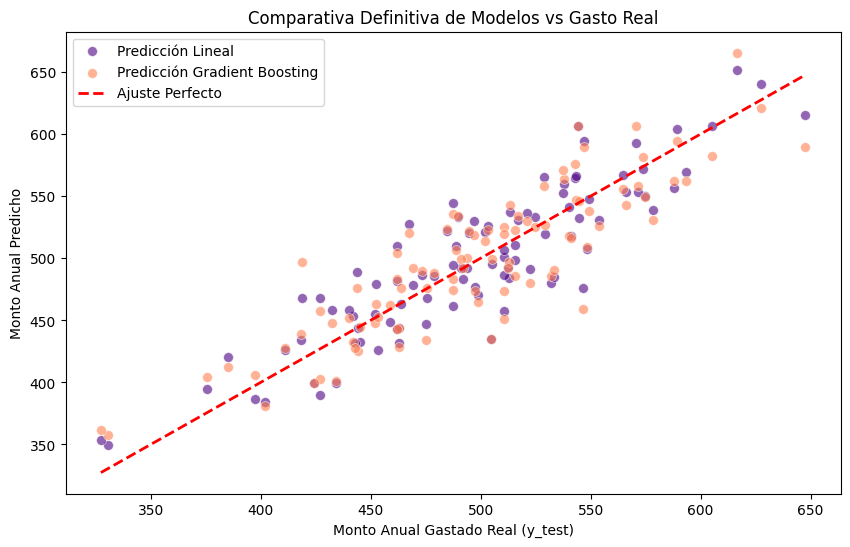

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=y_test,
    y=pred_lin,
    alpha=0.6,
    color="indigo",
    edgecolor="w",
    label="Predicción Lineal",
    s=50,
)
sns.scatterplot(
    x=y_test,
    y=pred_gbr,
    alpha=0.6,
    color="coral",
    edgecolor="w",
    label="Predicción Gradient Boosting",
    s=50,
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ajuste Perfecto",
)
plt.title("Comparativa Definitiva de Modelos vs Gasto Real")
plt.xlabel("Monto Anual Gastado Real (y_test)")
plt.ylabel("Monto Anual Predicho")
plt.legend()
plt.show()

#### 8.3 Reflexión: ¿Por qué Gradient Boosting no supera claramente a la Regresión Lineal?
Al visualizar nuestro diagrama de dispersión final confirmamos una sospecha técnica crucial: _las predicciones de nuestro sofisticado Ensamble Computacional son casi idénticas a nuestra simple aproximación inicial Lineal_.

**¿Se puede intentar mejorar aún más con ajustes?**. La respuesta analítica es que probablemente no mucho más.
Esto se debe intrínsecamente a la naturaleza originaria de los datos de *Ecommerce* importados: exhiben una relación matemática aditiva e intrínsecamente lineal sin interacciones ocultas complejas. En escenarios perfectamente lineales, un algoritmo avanzado basado en árboles (como *Gradient Boosting*) intentará emular una línea recta construyendo muchos escalones aserruchados, mientras que una *Regresión Lineal* común es lisa y llanamente la perfección teórica para ese escenario puntual.

Esta es una gigantesca lección en Ciencia de Datos formativa: **Los algoritmos complejos y de alto costo no garantizan vencer siempre; la topología de nuestros datos debe dictar qué herramienta es necesaria, no la sofisticación del algoritmo.**

## [Reporte Técnico](./technical_report.md)